#  Audio Similarity Using Pretrained Embeddings

### Install Required Packages

In [4]:
!pip install tensorflow tensorflow-datasets tensorflow-hub importlib-resources pydub
!pip install librosa seaborn matplotlib scikit-learn

### Import Required Libraries

In [5]:
import numpy as np
import pandas as pd

import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_datasets as tfds

import librosa

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import euclidean_distances

C:\Users\acer\anaconda3\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


### Load Speech Commands Dataset

In [7]:
dataset, info = tfds.load(
    "speech_commands",
    split="train",
    data_dir="D:/tfds_data",
    as_supervised=True,
    with_info=True
)
label_names = info.features["label"].names
print(label_names)

['down', 'go', 'left', 'no', 'off', 'on', 'right', 'stop', 'up', 'yes', '_silence_', '_unknown_']


### Load Pretrained YAMNet Model

In [8]:
yamnet_model = hub.load(
    "https://tfhub.dev/google/yamnet/1"
)

### Extract Few Audio Clips

In [13]:
audio_samples = []
audio_labels = []
num_samples = 10
for audio, label in dataset.take(num_samples):
    audio_samples.append(audio.numpy())
    audio_labels.append(label_names[label.numpy()])

### Extract Embeddings

In [14]:
def extract_embeddings(audio):
    scores, embeddings, spectrogram = yamnet_model(audio)
    mean_embedding = tf.reduce_mean(embeddings, axis=0)
    return mean_embedding.numpy()

### Generate Embeddings

In [16]:
embedding_list = []
for audio in audio_samples:
    emb = extract_embeddings(audio)
    embedding_list.append(emb)
embedding_matrix = np.array(embedding_list)

### Compute Cosine Similarity

In [17]:
similarity_matrix = cosine_similarity(embedding_matrix)

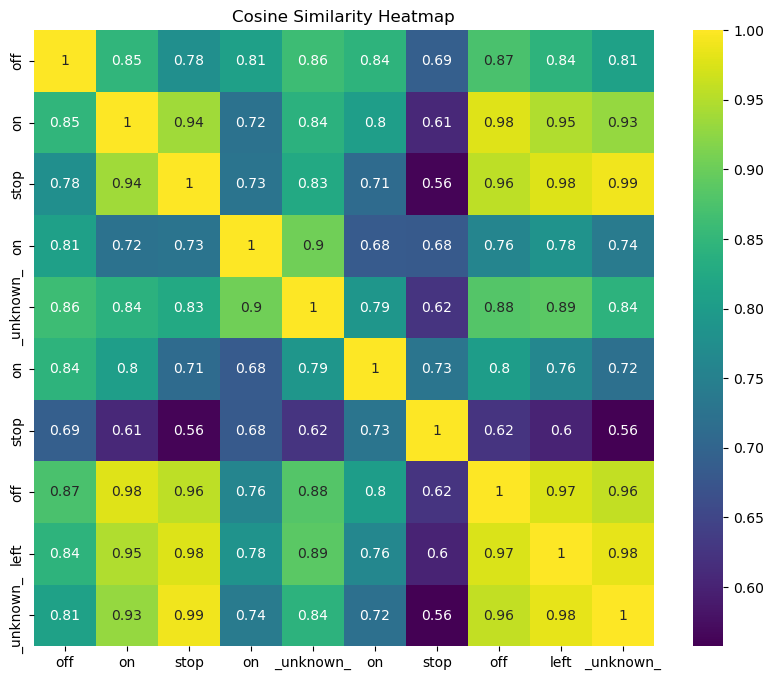

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="viridis",
    xticklabels=audio_labels,
    yticklabels=audio_labels
)
plt.title("Cosine Similarity Heatmap")
plt.show()

### Compute Euclidean Distance

In [21]:
distance_matrix = euclidean_distances(embedding_matrix)

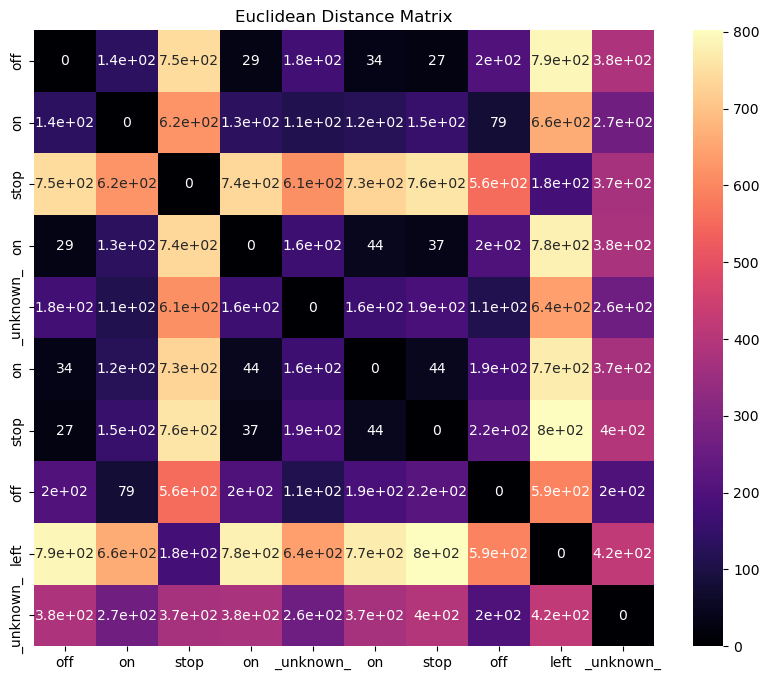

In [22]:
plt.figure(figsize=(10,8))
sns.heatmap(
    distance_matrix,
    annot=True,
    cmap="magma",
    xticklabels=audio_labels,
    yticklabels=audio_labels
)
plt.title("Euclidean Distance Matrix")
plt.show()